# 미분으로 보는 방정식·부등식

도함수로 **임계점·증감**을 알면

- 방정식 $f(x)=k$의 실근 개수
- 부등식 $f(x)>0$ 등의 해집합

을 그래프/증감표로 정리할 수 있다.

## 1. 방정식: $f(x)=0$의 근의 개수

In [6]:
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt

sp.init_printing()
x = sp.symbols('x', real=True)

f = x**3 - 3*x + 1
df = sp.diff(f, x)

crit = sorted(sp.solve(df, x))
print("f(x) =")
display(f)
print("임계점과 함숫값:")
for c in crit:
    print(f"  f({c}) = {f.subs(x, c)}")

# 극값의 부호로 실근 개수 추정
f_at_crit = [f.subs(x, c) for c in crit]
print("\n극값:", f_at_crit)

# Cardano 형식은 .is_real 이 False/None 일 수 있음 → real_roots 사용
real_roots = sp.real_roots(sp.Poly(f, x))
print(f"실근 개수 (real_roots): {len(real_roots)}")
display(real_roots)

f(x) =


임계점과 함숫값:
  f(-1) = 3
  f(1) = -1

극값: [3, -1]
실근 개수 (real_roots): 3


**아이디어**: <br>
=> 극댓값이 $>0$, 극솟값이 $<0$이면 $x$축과 세 번 만남 

**sp.real_roots(Poly)**: <br>
=> **실근만** 정확히 반환 (삼차 `solve`의 Cardano 형식은 `.is_real`이 실패하기 쉬움)

**주의**: <br>
=> `sp.solve` 결과에 `if r.is_real`을 걸면, 실제로는 실수인 근이 빠져 `[]`가 될 수 있다

## 2. $f(x)=k$ — $k$에 따른 근의 개수

In [7]:
# f의 치역 후보: 극값 사이/바깥
local_max = max(f_at_crit)
local_min = min(f_at_crit)
print(f"극대≈{local_max}, 극소≈{local_min}")

for k in [-3, 0, 1, 3]:
    # f(x) - k = 0 의 실근
    rts = sp.real_roots(sp.Poly(f - k, x))
    print(f"f(x)={k}: 실근 {len(rts)}개 → {[sp.N(r, 5) for r in rts]}")

극대≈3, 극소≈-1
f(x)=-3: 실근 1개 → [-2.1958]
f(x)=0: 실근 3개 → [-1.8794, 0.34730, 1.5321]
f(x)=1: 실근 3개 → [-1.7320, 0, 1.7320]
f(x)=3: 실근 3개 → [-1.0000, -1.0000, 2.0000]


## 3. 부등식: $f(x) > 0$

In [8]:
# 임계점·근으로 구간 분할 후 부호 확인
# (solve + .is_real 대신 real_roots — 삼차 Cardano 함정 방지)
zeros = sp.real_roots(sp.Poly(f, x))
bounds = [-sp.oo] + list(zeros) + [sp.oo]

def sample(L, R):
    """열린구간 (L, R) 안의 시험점 (양 끝 ∞ 처리 포함)"""
    if L == -sp.oo and R == sp.oo:
        return sp.Integer(0)
    if L == -sp.oo:
        return R - 1
    if R == sp.oo:
        return L + 1
    return (L + R) / 2

print("f(x) > 0 인 구간 탐색")
positive = []
for i in range(len(bounds) - 1):
    L, R = bounds[i], bounds[i + 1]
    test = sample(L, R)
    # 수치 비교: sympy Relational / NaN 비교 회피
    val = sp.N(f.subs(x, test))
    if val > 0:
        positive.append((L, R))
        print(f"  ({sp.N(L, 4)}, {sp.N(R, 4)}): f>0  (시험점 {sp.N(test, 4)}, f={val})")
    else:
        print(f"  ({sp.N(L, 4)}, {sp.N(R, 4)}): f≤0  (시험점 {sp.N(test, 4)}, f={val})")

print("\n해: 위 열린구간들의 합집합")
display(positive)

f(x) > 0 인 구간 탐색
  (-oo, -1.879): f≤0  (시험점 -2.879, f=-14.2344223834293)
  (-1.879, 0.3473): f>0  (시험점 -0.7660, f=2.84859999701770)
  (0.3473, 1.532): f≤0  (시험점 0.9397, f=-0.989308396768294)
  (1.532, oo): f>0  (시험점 2.532, f=9.63815572471545)

해: 위 열린구간들의 합집합


## 4. 그래프

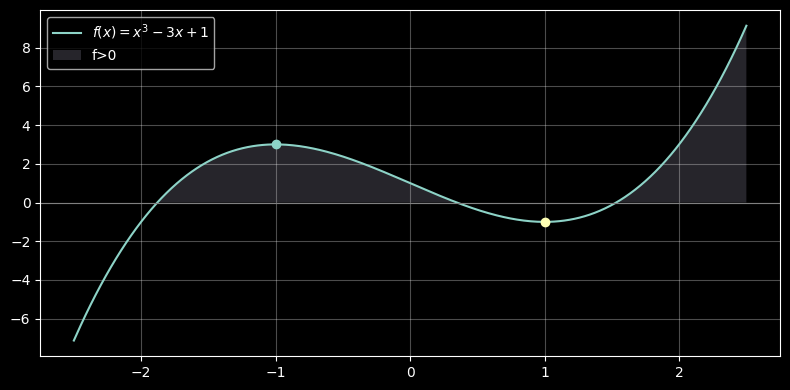

In [9]:
f_num = sp.lambdify(x, f, 'numpy')
xs = np.linspace(-2.5, 2.5, 400)
ys = f_num(xs)

plt.figure(figsize=(8, 4))
plt.plot(xs, ys, label=r"$f(x)=x^3-3x+1$")
plt.axhline(0, color="gray", lw=0.8)
for c in crit:
    plt.scatter([float(c)], [float(f.subs(x, c))], zorder=5)
plt.fill_between(xs, 0, ys, where=(ys > 0), alpha=0.2, label="f>0")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()